In [6]:
import os
import shutil
from google.colab import drive

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Define Paths
DRIVE_PATH = '/content/drive/MyDrive/medicalMNIST'
LOCAL_PATH = '/content/medicalMNIST'

# 3. Copy files to local Colab storage for FAST training
if not os.path.exists(LOCAL_PATH):
    print("Copying dataset from Drive to local Colab storage... (This takes a minute or two but saves hours!)")
    shutil.copytree(DRIVE_PATH, LOCAL_PATH)
    print("Copy complete!")
else:
    print("Dataset already exists locally.")

# 4. Remove the 'checkpoints' folder so tf.data doesn't think it's a class of images
if os.path.exists(os.path.join(LOCAL_PATH, 'checkpoints')):
    shutil.rmtree(os.path.join(LOCAL_PATH, 'checkpoints'))
    print("Removed 'checkpoints' folder from training data.")

DATA_ROOT = LOCAL_PATH
print(f"Dataset root set to: {DATA_ROOT}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset already exists locally.
Dataset root set to: /content/medicalMNIST


In [7]:
%%writefile dataset.py
import tensorflow as tf
from tensorflow import keras

def get_datasets(data_dir, batch_size=128, img_size=(64, 64), val_split=0.15, seed=42):
    # Explicitly define classes to ignore the 'checkpoints' folder
    VALID_CLASSES = ['AbdomenCT', 'BreastMRI', 'CXR', 'ChestCT', 'Hand', 'HeadCT']

    # 1. Base Datasets (We load labels here as 'int' to satisfy Keras, but will discard them later)
    train_ds_base = keras.utils.image_dataset_from_directory(
        data_dir, validation_split=val_split, subset="training",
        seed=seed, color_mode='grayscale', image_size=img_size,
        batch_size=batch_size, label_mode='int', class_names=VALID_CLASSES
    )

    val_ds_base = keras.utils.image_dataset_from_directory(
        data_dir, validation_split=val_split, subset="validation",
        seed=seed, color_mode='grayscale', image_size=img_size,
        batch_size=batch_size, label_mode='int', class_names=VALID_CLASSES
    )

    # 2. Evaluation Dataset
    val_ds_labels = keras.utils.image_dataset_from_directory(
        data_dir, validation_split=val_split, subset="validation",
        seed=seed, color_mode='grayscale', image_size=img_size,
        batch_size=batch_size, label_mode='int', class_names=VALID_CLASSES
    )
    class_names = val_ds_labels.class_names

    # 3. Normalization & Mapping
    normalization_layer = keras.layers.Rescaling(1./255)

    # We now accept the (image, label) pair, but discard the label and return (image, image)
    def prepare_for_training(x, y):
        x = normalization_layer(x)
        return x, x

    def prepare_for_eval(x, y):
        return normalization_layer(x), y

    # Apply mapping, CACHE IN RAM, and optimize performance
    train_ds = train_ds_base.map(prepare_for_training, num_parallel_calls=tf.data.AUTOTUNE)
    train_ds = train_ds.cache().prefetch(tf.data.AUTOTUNE)

    val_ds = val_ds_base.map(prepare_for_training, num_parallel_calls=tf.data.AUTOTUNE)
    val_ds = val_ds.cache().prefetch(tf.data.AUTOTUNE)

    val_ds_eval = val_ds_labels.map(prepare_for_eval, num_parallel_calls=tf.data.AUTOTUNE)
    val_ds_eval = val_ds_eval.cache().prefetch(tf.data.AUTOTUNE)

    return train_ds, val_ds, val_ds_eval, class_names

Overwriting dataset.py


In [8]:
%%writefile models.py
import tensorflow as tf
from tensorflow import keras
from keras import layers

# ── Autoencoder (AE) ───────────────────────────────────────────────────────
def build_ae(latent_dim=64, img_size=(64, 64, 1)):
    # ENCODER
    encoder_inputs = keras.Input(shape=img_size)
    x = layers.Conv2D(32, 4, strides=2, padding="same", use_bias=False)(encoder_inputs)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.2)(x)

    x = layers.Conv2D(64, 4, strides=2, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.2)(x)

    x = layers.Conv2D(128, 4, strides=2, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.2)(x)

    x = layers.Conv2D(256, 4, strides=2, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.2)(x)

    x = layers.Flatten()(x)
    latent_outputs = layers.Dense(latent_dim)(x)
    encoder = keras.Model(encoder_inputs, latent_outputs, name="encoder")

    # DECODER
    latent_inputs = keras.Input(shape=(latent_dim,))
    x = layers.Dense(4 * 4 * 256, activation="relu")(latent_inputs)
    x = layers.Reshape((4, 4, 256))(x)

    x = layers.Conv2DTranspose(128, 4, strides=2, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2DTranspose(64, 4, strides=2, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2DTranspose(32, 4, strides=2, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    decoder_outputs = layers.Conv2DTranspose(1, 4, strides=2, padding="same", activation="sigmoid")(x)
    decoder = keras.Model(latent_inputs, decoder_outputs, name="decoder")

    # COMBINED AE
    ae_outputs = decoder(encoder(encoder_inputs))
    ae = keras.Model(encoder_inputs, ae_outputs, name="autoencoder")
    return ae, encoder, decoder

# ── Variational Autoencoder (VAE) ──────────────────────────────────────────
class Sampling(layers.Layer):
    """Uses (z_mean, z_log_var) to sample z, the vector encoding a digit."""
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.keras.backend.random_normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

def build_vae(latent_dim=64, img_size=(64, 64, 1)):
    # VAE ENCODER
    encoder_inputs = keras.Input(shape=img_size)
    x = layers.Conv2D(32, 4, strides=2, padding="same", use_bias=False)(encoder_inputs)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.2)(x)

    x = layers.Conv2D(64, 4, strides=2, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.2)(x)

    x = layers.Conv2D(128, 4, strides=2, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.2)(x)

    x = layers.Conv2D(256, 4, strides=2, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.2)(x)

    x = layers.Flatten()(x)
    z_mean = layers.Dense(latent_dim, name="z_mean")(x)
    z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
    z = Sampling()([z_mean, z_log_var])
    encoder = keras.Model(encoder_inputs, [z_mean, z_log_var, z], name="vae_encoder")

    # VAE DECODER (Reuses AE structure)
    _, _, decoder = build_ae(latent_dim=latent_dim, img_size=img_size)

    return VAEModel(encoder, decoder), encoder, decoder

class VAEModel(keras.Model):
    """Custom training step to compute ELBO (Reconstruction + KL Loss)"""
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.reconstruction_loss_tracker, self.kl_loss_tracker]

    def train_step(self, data):
        x, _ = data
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(x)
            reconstruction = self.decoder(z)

            # FIXED: Pure TF mathematical MSE calculation to avoid Keras 3 namespace issues
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(tf.square(x - reconstruction), axis=[1, 2, 3])
            )

            # KL Divergence logic
            kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
            total_loss = reconstruction_loss + kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {"loss": self.total_loss_tracker.result(), "recon_loss": self.reconstruction_loss_tracker.result(), "kl_loss": self.kl_loss_tracker.result()}

    def test_step(self, data):
        x, _ = data
        z_mean, z_log_var, z = self.encoder(x)
        reconstruction = self.decoder(z)

        # FIXED: Pure TF mathematical MSE calculation
        reconstruction_loss = tf.reduce_mean(
            tf.reduce_sum(tf.square(x - reconstruction), axis=[1, 2, 3])
        )

        kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
        kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
        total_loss = reconstruction_loss + kl_loss

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {"loss": self.total_loss_tracker.result(), "recon_loss": self.reconstruction_loss_tracker.result(), "kl_loss": self.kl_loss_tracker.result()}

Overwriting models.py


In [14]:
%%writefile utils.py
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from sklearn.manifold import TSNE

def show_reconstructions(model, ds, n=8, is_vae=False):
    for x_batch, _ in ds.take(1):
        x_batch = x_batch[:n]
        break

    if is_vae:
        _, _, z = model.encoder(x_batch)
        x_recon = model.decoder(z).numpy()
    else:
        x_recon = model.predict(x_batch, verbose=0)

    x_batch = x_batch.numpy()
    mse_vals = np.mean((x_batch - x_recon) ** 2, axis=(1, 2, 3))

    fig, axes = plt.subplots(3, n, figsize=(2.2 * n, 7))
    for i in range(n):
        axes[0, i].imshow(x_batch[i].squeeze(), cmap='gray', vmin=0, vmax=1)
        axes[0, i].axis('off')

        axes[1, i].imshow(x_recon[i].squeeze(), cmap='gray', vmin=0, vmax=1)
        axes[1, i].set_title(f'MSE={mse_vals[i]:.4f}', fontsize=7)
        axes[1, i].axis('off')

        err = np.abs(x_batch[i] - x_recon[i]).squeeze()
        axes[2, i].imshow(err, cmap='hot', vmin=0, vmax=0.5)
        axes[2, i].axis('off')
    plt.tight_layout()
    plt.show()

# FIXED: We now pass the 'encoder' directly instead of the full model
def plot_tsne(encoder, ds_eval, class_names, is_vae=False):
    all_z, all_y = [], []
    for x, y in ds_eval.take(20):
        if is_vae:
            z, _, _ = encoder(x)
        else:
            z = encoder(x)
        all_z.extend(z.numpy())
        all_y.extend(y.numpy())

    all_z = np.array(all_z)
    all_y = np.array(all_y)

    tsne = TSNE(n_components=2, random_state=42)
    z_2d = tsne.fit_transform(all_z)

    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(z_2d[:, 0], z_2d[:, 1], c=all_y, cmap='tab10', alpha=0.6, s=10)
    plt.legend(handles=scatter.legend_elements()[0], labels=class_names)
    plt.title("Latent Space Visualization (t-SNE)")
    plt.axis('off')
    plt.show()

def generate_samples(vae_decoder, latent_dim=64, n=32):
    random_latent_vectors = tf.random.normal(shape=(n, latent_dim))
    generated_images = vae_decoder(random_latent_vectors).numpy()

    fig, axes = plt.subplots(4, 8, figsize=(14, 7))
    fig.suptitle('VAE — Generated Samples from Prior z ~ N(0, I)', fontsize=13)
    for i, ax in enumerate(axes.flat):
        ax.imshow(generated_images[i].squeeze(), cmap='gray', vmin=0, vmax=1)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

Overwriting utils.py


In [15]:
import dataset
import models
import utils
import tensorflow as tf
import importlib

# Force Python to load the newest version of dataset.py
importlib.reload(dataset)

# 1. Load Data
BATCH_SIZE = 128
train_ds, val_ds, val_ds_eval, class_names = dataset.get_datasets(DATA_ROOT, batch_size=BATCH_SIZE)
print(f"✅ Data loaded. Classes found: {class_names}")

# 2. Compile and Train Autoencoder (AE)
print("\n" + "="*40)
print("  TRAINING STANDARD AUTOENCODER")
print("="*40)
ae, ae_encoder, ae_decoder = models.build_ae()
ae.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), loss="mse")

ae.summary() # Prints the exact architecture for your report

ae_history = ae.fit(
    train_ds,
    epochs=20,
    validation_data=val_ds
)

# Print final AE metrics to copy/paste
final_ae_train_loss = ae_history.history['loss'][-1]
final_ae_val_loss = ae_history.history['val_loss'][-1]
print(f"\n🏆 FINAL AE METRICS -> Train MSE: {final_ae_train_loss:.5f} | Val MSE: {final_ae_val_loss:.5f}")


# 3. Compile and Train Variational Autoencoder (VAE)
print("\n" + "="*40)
print("  TRAINING VARIATIONAL AUTOENCODER")
print("="*40)
vae, vae_encoder, vae_decoder = models.build_vae()
vae.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3))

vae.summary() # Prints the VAE architecture

vae_history = vae.fit(
    train_ds,
    epochs=20,
    validation_data=val_ds
)

# Print final VAE metrics to copy/paste
final_vae_val_loss = vae_history.history['val_loss'][-1]
final_vae_val_recon = vae_history.history['val_recon_loss'][-1]
final_vae_val_kl = vae_history.history['val_kl_loss'][-1]
print(f"\n🏆 FINAL VAE METRICS -> Total Val Loss: {final_vae_val_loss:.5f}")
print(f"   ↳ Reconstruction Loss: {final_vae_val_recon:.5f}")
print(f"   ↳ KL Divergence Loss: {final_vae_val_kl:.5f}")

# 4. Save the models
ae.save_weights('/content/drive/MyDrive/medicalMNIST/ae_weights.weights.h5')
vae_encoder.save_weights('/content/drive/MyDrive/medicalMNIST/vae_encoder.weights.h5')
vae_decoder.save_weights('/content/drive/MyDrive/medicalMNIST/vae_decoder.weights.h5')
print("\n✅ Model weights saved to Google Drive.")


Found 55128 files belonging to 6 classes.
Using 46859 files for training.
Found 55128 files belonging to 6 classes.
Using 8269 files for validation.
Found 55128 files belonging to 6 classes.
Using 8269 files for validation.
✅ Data loaded. Classes found: ['AbdomenCT', 'BreastMRI', 'CXR', 'ChestCT', 'Hand', 'HeadCT']

  TRAINING STANDARD AUTOENCODER


Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Functional)            │ (None, 64)             │       952,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 64, 64, 1)      │       955,777 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,908,545 (7.28 MB)

 Trainable params: 1,907,137 (7.28 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vae_encoder (Functional)        │ ((None, 64), (None,    │     1,214,976 │
│                                 │ 64), (None, 64))       │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 64, 64, 1)      │       955,777 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,170,753 (8.28 MB)

 Trainable params: 2,169,345 (8.28 MB)

 Non-trainable params: 1,408 (5.50 KB)

Epoch 1/20
367/367 ━━━━━━━━━━━━━━━━━━━━ 23s 41ms/step - kl_loss: 12.3237 - loss: 130.1027 - recon_loss: 117.7790 - val_kl_loss: 15.6914 - val_loss: 81.0023 - val_recon_loss: 65.3109
Epoch 2/20
367/367 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - kl_loss: 15.0926 - loss: 72.0351 - recon_loss: 56.9425 - val_kl_loss: 14.9693 - val_loss: 67.7234 - val_recon_loss: 52.7541
Epoch 3/20
367/367 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - kl_loss: 15.5449 - loss: 64.0820 - recon_loss: 48.5371 - val_kl_loss: 15.4635 - val_loss: 62.5429 - val_recon_loss: 47.0794
Epoch 4/20
367/367 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - kl_loss: 15.8254 - loss: 60.4884 - recon_loss: 44.6630 - val_kl_loss: 14.6511 - val_loss: 61.1193 - val_recon_loss: 46.4681
Epoch 5/20
367/367 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - kl_loss: 15.9793 - loss: 58.4050 - recon_loss: 42.4257 - val_kl_loss: 15.6327 - val_loss: 58.2337 - val_recon_loss: 42.6011
Epoch 6/20
367/367 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - kl_loss: 16.1100 - loss: 57.0055 - recon_loss: 


--- Generating Autoencoder Reconstructions ---


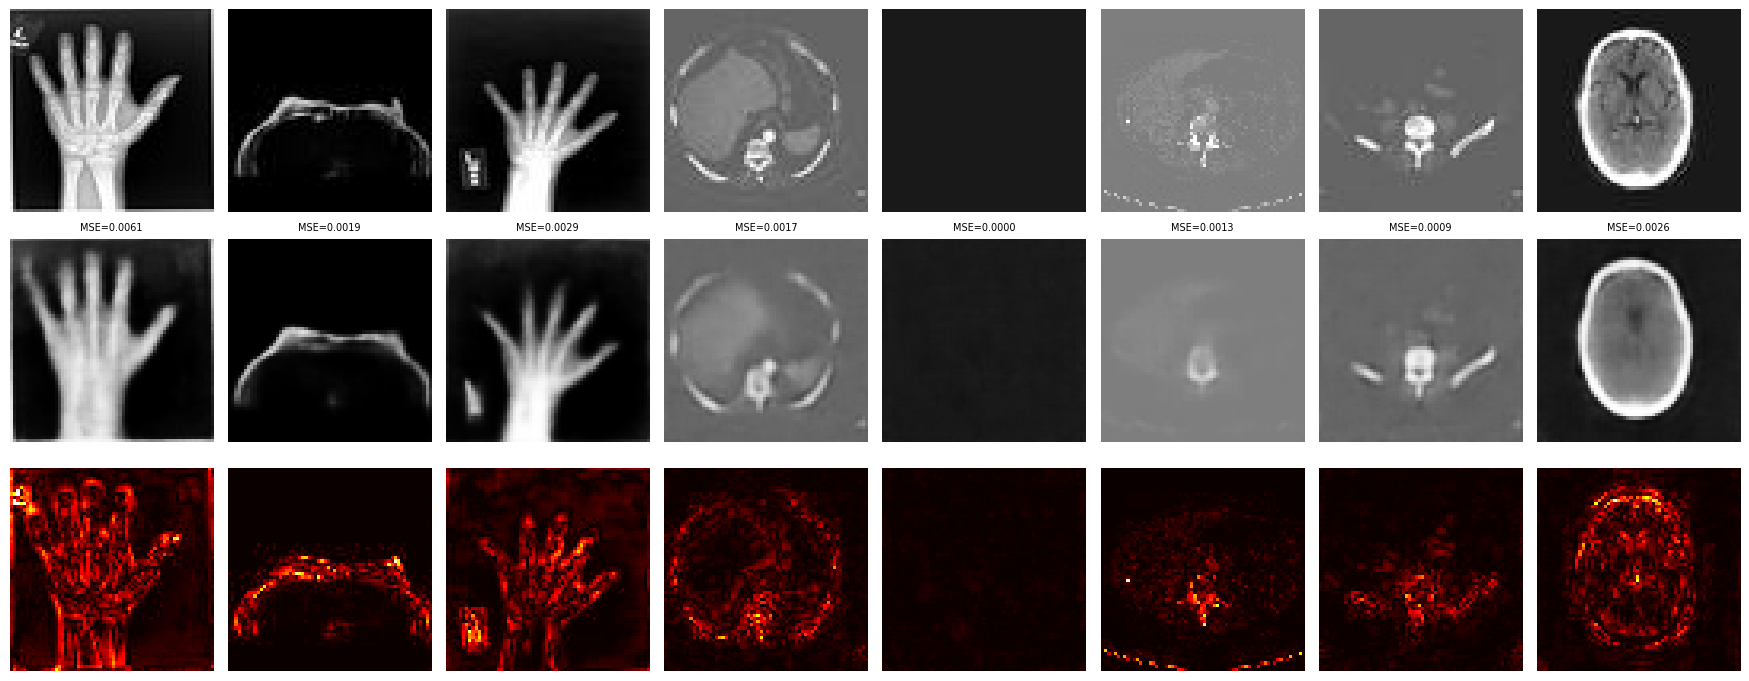


--- Generating VAE Reconstructions ---


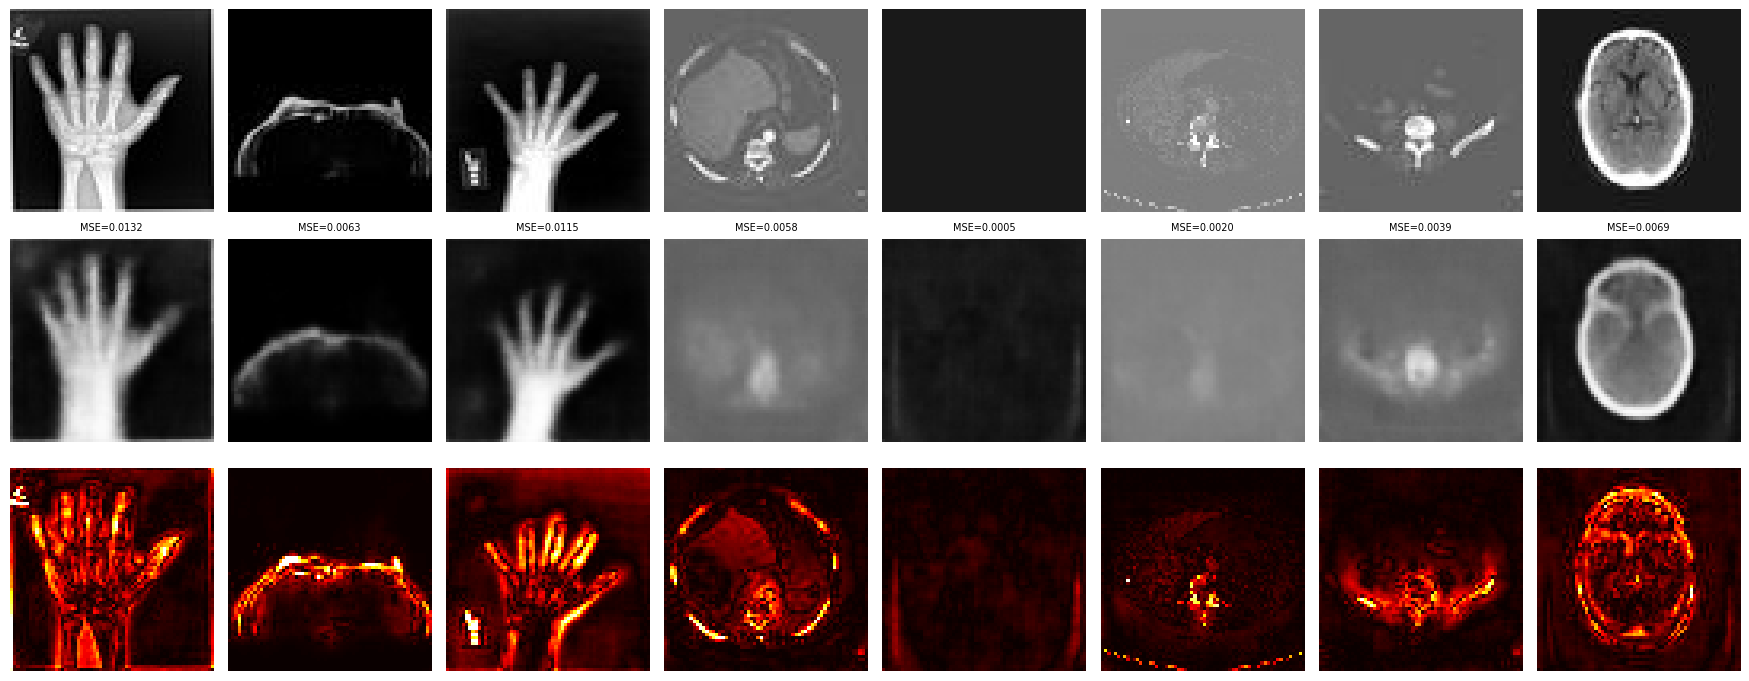

In [16]:

# 5. Visualizations
print("\n--- Generating Autoencoder Reconstructions ---")
utils.show_reconstructions(ae, val_ds, is_vae=False)

print("\n--- Generating VAE Reconstructions ---")
utils.show_reconstructions(vae, val_ds, is_vae=True)



--- Generating AE Latent Space (t-SNE) ---


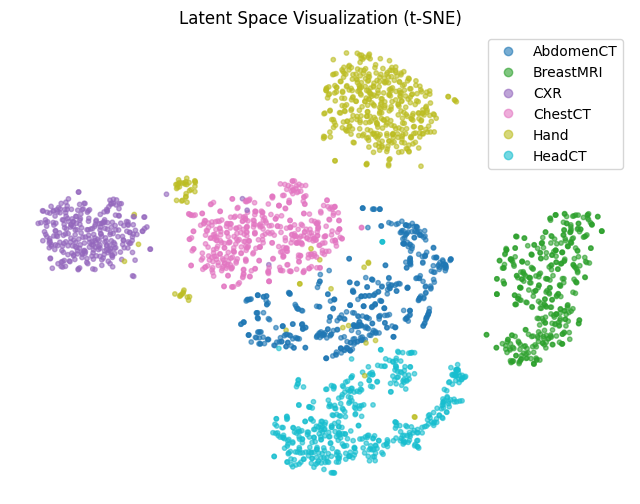


--- Generating VAE Latent Space (t-SNE) ---


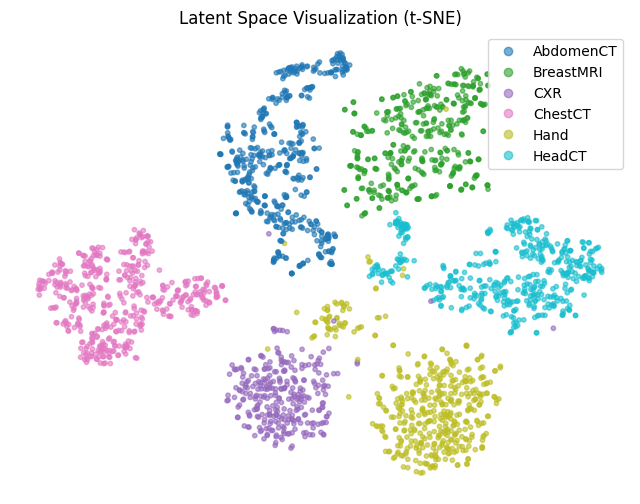


--- Generating New Medical Images from VAE Latent Space ---


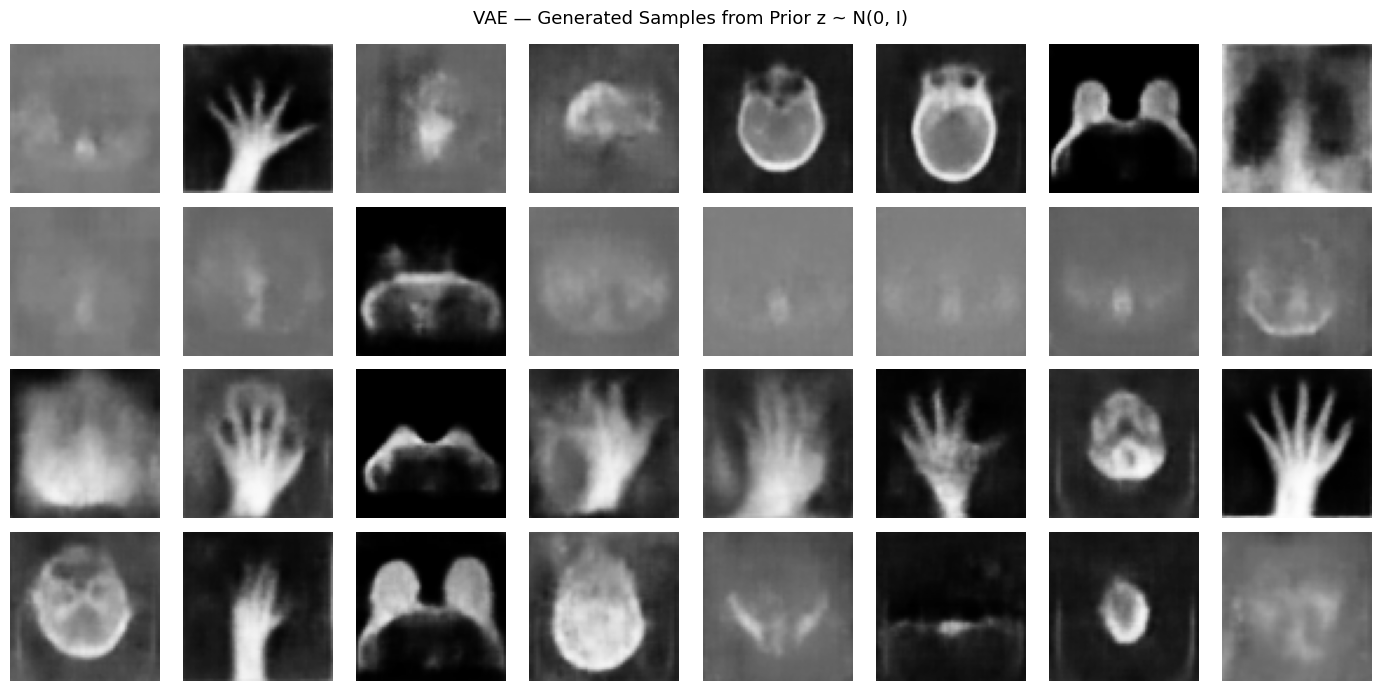

In [17]:

import importlib
importlib.reload(utils)

print("\n--- Generating AE Latent Space (t-SNE) ---")
# Passing ae_encoder instead of ae
utils.plot_tsne(ae_encoder, val_ds_eval, class_names, is_vae=False)

print("\n--- Generating VAE Latent Space (t-SNE) ---")
# Passing vae_encoder instead of vae
utils.plot_tsne(vae_encoder, val_ds_eval, class_names, is_vae=True)

print("\n--- Generating New Medical Images from VAE Latent Space ---")
utils.generate_samples(vae_decoder)